In [1]:
# Imports and settings
# 说明：此单元导入依赖，设置随机种子与设备，准备后续回归实验所需工具。
import os
import torch
import random
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
# PyG 数据结构与关系图卷积
from torch_geometric.data import Data
from torch_geometric.nn import RGCNConv
# 用于保存结果和绘图（可选）
import json
import matplotlib.pyplot as plt

# Reproducibility and device
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device ->', device)


device -> cuda


In [2]:
# Load hetero graph and node features (fallback to CSV)
# 将此单元插入在导入单元之后，负责载入预生成的异构图与节点特征
hetero_path = 'data/hetero_edges.pt'
if not os.path.exists(hetero_path):
    raise FileNotFoundError(hetero_path)
hetero = torch.load(hetero_path)
print('Loaded hetero object type:', type(hetero))

# 有些保存格式会把真正的 HeteroData 放在 dict['graph'] 里
graph = hetero['graph'] if isinstance(hetero, dict) and 'graph' in hetero else hetero
print('Resolved graph type:', type(graph))

# 尝试从 graph 提取 stock 节点特征，支持多种保存格式
x = None
try:
    stock_data = graph['stock']
    x = stock_data.x if hasattr(stock_data, 'x') else None
except Exception:
    x = getattr(graph, 'x', None)

if x is None and isinstance(hetero, dict) and 'stock' in hetero:
    stock_data = hetero['stock']
    x = stock_data.x if hasattr(stock_data, 'x') else None

if x is None:
    feat_df = pd.read_csv('data/node_feats_allx10.csv')
    feat_df = feat_df.fillna(0)
    x = torch.tensor(feat_df.iloc[:, 1:].values, dtype=torch.float)

print('x.shape =', x.shape)


Loaded hetero object type: <class 'dict'>
Resolved graph type: <class 'torch_geometric.data.hetero_data.HeteroData'>
x.shape = torch.Size([5207, 10])


In [ ]:
# Training and evaluation utilities for regression
# 说明：定义训练、评估与窗口划分工具，便于后续做 walk-forward 训练。
import numpy as np
import torch.optim as optim

def safe_mean(values):
    """计算均值（忽略 NaN）。"""
    valid = [v for v in values if not np.isnan(v)]
    return float(np.mean(valid)) if len(valid) > 0 else float('nan')


def compute_ic_np(y_true, y_pred, mask):
    """计算 IC（Pearson 相关系数）。"""
    if mask.sum() < 2:
        return float('nan')
    y_true_mask = y_true[mask]
    y_pred_mask = y_pred[mask]
    try:
        return float(np.corrcoef(y_true_mask, y_pred_mask)[0, 1])
    except Exception:
        return float('nan')


def masked_mse_torch(pred, target, mask):
    """计算 masked MSE。"""
    if mask.sum() == 0:
        return torch.tensor(float('nan'), device=pred.device)
    diff = pred[mask] - target[mask]
    return (diff * diff).mean()


def masked_ic_torch(pred, target, mask, eps=1e-8):
    """计算 masked IC（可微分）。"""
    if mask.sum() < 2:
        return torch.tensor(float('nan'), device=pred.device)
    pred_centered = pred[mask] - pred[mask].mean()
    target_centered = target[mask] - target[mask].mean()
    denom = pred_centered.std(unbiased=False) * target_centered.std(unbiased=False) + eps
    return (pred_centered * target_centered).mean() / denom


def train_one_day(model, data, optimizer, loss_cfg):
    """单日训练一步。"""
    model.train()
    optimizer.zero_grad()
    out = model(data.x.to(device), data.edge_index.to(device), data.edge_type.to(device))
    y = data.y.to(device)
    mask = data.train_mask.to(device)
    if mask.sum() == 0:
        return float('nan')
    pred = out[mask]
    target = y[mask].float()
    mse_loss = masked_mse_torch(pred, target, torch.ones_like(target, dtype=torch.bool))
    ic_value = masked_ic_torch(pred, target, torch.ones_like(target, dtype=torch.bool))
    if torch.isnan(ic_value):
        ic_value = torch.tensor(0.0, device=pred.device)
    loss = mse_loss + loss_cfg['ic_weight'] * (1.0 - ic_value)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), loss_cfg['grad_clip'])
    optimizer.step()
    return float(loss.item())


def eval_one_day(model, data):
    """单日评估，返回 mse 与 ic。"""
    model.eval()
    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device), data.edge_type.to(device))
        out_np = out.cpu().numpy()
        y_np = data.y.cpu().numpy()
        mask = data.val_mask.cpu().numpy() if hasattr(data, 'val_mask') else ~np.isnan(y_np)
        valid = mask & (~np.isnan(y_np))
        if valid.sum() < 2:
            return float('nan'), float('nan')
        mse = mean_squared_error(y_np[valid], out_np[valid])
        ic = compute_ic_np(y_np, out_np, valid)
    return float(mse), float(ic)


def eval_days(model, data_list, day_indices):
    """评估多日指标并汇总。"""
    mse_list = []
    ic_list = []
    for day_index in day_indices:
        mse, ic = eval_one_day(model, data_list[day_index])
        mse_list.append(mse)
        ic_list.append(ic)
    return safe_mean(mse_list), safe_mean(ic_list)


def train_epoch_days(model, data_list, day_indices, optimizer, loss_cfg):
    """训练多日并汇总 loss。"""
    loss_list = []
    for day_index in day_indices:
        loss = train_one_day(model, data_list[day_index], optimizer, loss_cfg)
        if not np.isnan(loss):
            loss_list.append(loss)
    return safe_mean(loss_list)


def build_window_splits(total_days, train_window, val_window, step):
    """生成滑动窗口切分。"""
    starts = list(range(0, total_days - train_window - val_window + 1, step))
    if len(starts) == 0:
        raise ValueError('滑动窗口数量为 0，请调整 train_window/val_window/step。')
    return [(list(range(s, s + train_window)), list(range(s + train_window, s + train_window + val_window))) for s in starts]


def train_one_window(model, optimizer, data_list, train_idx, val_idx, train_cfg, loss_cfg):
    """训练一个窗口并早停。"""
    best_state = None
    best_ic = -1e9
    bad_epochs = 0
    history = {'train_loss': [], 'val_mse': [], 'val_ic': []}
    for epoch in range(1, train_cfg['epochs'] + 1):
        train_loss = train_epoch_days(model, data_list, train_idx, optimizer, loss_cfg)
        val_mse, val_ic = eval_days(model, data_list, val_idx)
        history['train_loss'].append(train_loss)
        history['val_mse'].append(val_mse)
        history['val_ic'].append(val_ic)
        if not np.isnan(val_ic) and val_ic > best_ic:
            best_ic = val_ic
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= train_cfg['patience']:
            break
    return best_state, best_ic, history

In [4]:
# Regression model definition (StockRGCN_Regression)
# 说明：两层 RGCN + 线性回归头，输出每个节点的连续预测值（下一日收益率）。
import torch.nn.functional as F
class StockRGCN_Regression(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_relations=3):
        super().__init__()
        self.conv1 = RGCNConv(in_channels, hidden_channels, num_relations)
        self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations)
        self.regressor = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, edge_type):
        # x: [N, F], edge_index: [2, E], edge_type: [E]
        x = self.conv1(x, edge_index, edge_type)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_type)
        out = self.regressor(x).squeeze(-1)  # -> [N]
        return out


In [ ]:
# Build combined edge_index and edge_type for relations; generate continuous labels (next-day returns)
# 说明：按策略生成回归标签，并构造 PyG Data 对象用于 walk-forward 训练。
rel_names = ['same_industry', 'same_concept', 'high_corr']

# 有些 pt 文件会把真正的 HeteroData 放在 dict['graph'] 中
graph = hetero['graph'] if isinstance(hetero, dict) and 'graph' in hetero else hetero


def resolve_edge_index(graph_obj, relation_name):
    """在不同保存格式中，尽量按 relation_name 找到对应的 edge_index。"""
    edge_index_dict = getattr(graph_obj, 'edge_index_dict', None)
    if edge_index_dict is not None:
        for edge_key, edge_index in edge_index_dict.items():
            key_text = str(edge_key)
            if relation_name == key_text or relation_name in key_text:
                return edge_index
            if isinstance(edge_key, tuple):
                joined = '::'.join(map(str, edge_key))
                if relation_name in joined:
                    return edge_index
    try:
        candidate = graph_obj[relation_name]
        if isinstance(candidate, dict) and 'edge_index' in candidate:
            return candidate['edge_index']
        return candidate
    except Exception:
        pass
    try:
        for edge_key in graph_obj.keys():
            key_text = str(edge_key)
            if relation_name in key_text:
                candidate = graph_obj[edge_key]
                if isinstance(candidate, dict) and 'edge_index' in candidate:
                    return candidate['edge_index']
                return candidate
    except Exception:
        pass
    return None


edge_index_list = []
edge_type_list = []
for i, rel in enumerate(rel_names):
    ei = resolve_edge_index(graph, rel)
    if ei is None:
        available_keys = []
        try:
            available_keys = list(graph.keys())
        except Exception:
            pass
        try:
            edge_dict_keys = list(getattr(graph, 'edge_index_dict', {}).keys())
        except Exception:
            edge_dict_keys = []
        raise KeyError(
            f'Cannot find edge_index for relation {rel} in {hetero_path}. '
            f'Available keys={available_keys}, edge_index_dict keys={edge_dict_keys}'
        )
    ei = ei.to(torch.long)
    edge_index_list.append(ei)
    edge_type_list.append(torch.full((ei.size(1),), i, dtype=torch.long))

edge_index = torch.cat(edge_index_list, dim=1)
edge_type = torch.cat(edge_type_list, dim=0)
print('Combined edge_index shape:', edge_index.shape, 'edge_type shape:', edge_type.shape)

# 节点特征标准化（避免尺度漂移）
x = x.float()
x_mean = x.mean(dim=0, keepdim=True)  # 特征均值
x_std = x.std(dim=0, keepdim=True)  # 特征标准差
x_std = torch.where(x_std < 1e-6, torch.ones_like(x_std), x_std)
x = (x - x_mean) / x_std
print('特征标准化完成')

# 读取逐日收益（第一列通常为 trade_date），并构造下一日收益作为连续标签
rets_df = pd.read_csv('data/daily_returns.csv')
trade_date_column = 'trade_date' if 'trade_date' in rets_df.columns else rets_df.columns[0]
trade_dates = pd.to_datetime(rets_df[trade_date_column], errors='coerce')
valid_date_mask = trade_dates.notna()
if not valid_date_mask.all():
    rets_df = rets_df.loc[valid_date_mask].reset_index(drop=True)
    trade_dates = trade_dates.loc[valid_date_mask].reset_index(drop=True)

rets = rets_df.drop(columns=[trade_date_column], errors='ignore')
rets = rets.apply(pd.to_numeric, errors='coerce')
rets.index = trade_dates
print('returns shape (dates x stocks):', rets.shape)

# 选取回看窗口（最近 window+1 天），并用 shift(-1) 生成 T -> T+1 的标签
window = 250  # 回看窗口长度
if rets.shape[0] < window + 1:
    window = rets.shape[0] - 1
rets_recent = rets.tail(window + 1).copy()
future = rets_recent.shift(-1).iloc[:-1]
labels_df = future
print('labels_df shape (window x stocks):', labels_df.shape)

if labels_df.shape[1] != x.size(0):
    raise ValueError('标签列数与节点数量不一致，请检查数据对齐。')

# 滑动窗口参数
total_days = labels_df.shape[0]  # 总天数
train_window = 200  # 训练窗口天数
val_window = 50  # 验证窗口天数
step = 10  # 滑动步长
if total_days < train_window + val_window:
    train_window = max(1, total_days - 1)
    val_window = max(1, total_days - train_window)
if step < 1:
    step = 1

# 构造每日快照数据（mask 只负责 NaN 过滤）
data_list = []
for t in range(total_days):
    y = torch.tensor(labels_df.iloc[t].values, dtype=torch.float)
    mask = ~torch.isnan(y)
    data = Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y, train_mask=mask, val_mask=mask)
    data_list.append(data)

window_splits = build_window_splits(total_days, train_window, val_window, step)
print('滑动窗口数量:', len(window_splits), 'train_window:', train_window, 'val_window:', val_window, 'step:', step)

Combined edge_index shape: torch.Size([2, 322616]) edge_type shape: torch.Size([322616])
returns shape (dates x stocks): (130, 5207)
labels_df shape (window x stocks): (129, 5207)
滑动窗口数量: 1 train_window: 128 val_window: 1 step: 10


Epoch 001 train_loss=95.367396 val_mse=1.649145 val_ic=-0.045626
Epoch 005 train_loss=0.280005 val_mse=0.236560 val_ic=0.026991
Epoch 010 train_loss=0.118418 val_mse=0.107470 val_ic=0.006311
Epoch 015 train_loss=0.062989 val_mse=0.068872 val_ic=-0.013973
Epoch 020 train_loss=0.072008 val_mse=0.047027 val_ic=-0.016652
Epoch 025 train_loss=0.160355 val_mse=0.117534 val_ic=-0.050204
Epoch 030 train_loss=0.531063 val_mse=0.071460 val_ic=-0.035012
Epoch 035 train_loss=0.143145 val_mse=0.029460 val_ic=0.008611
Epoch 040 train_loss=0.112658 val_mse=0.081119 val_ic=0.028875
Epoch 045 train_loss=0.038033 val_mse=0.059910 val_ic=-0.043251
Epoch 050 train_loss=0.133627 val_mse=0.067706 val_ic=0.021169
训练完成，最佳 IC: 0.03354951429333983
Saved training_curves.png and metrics.json


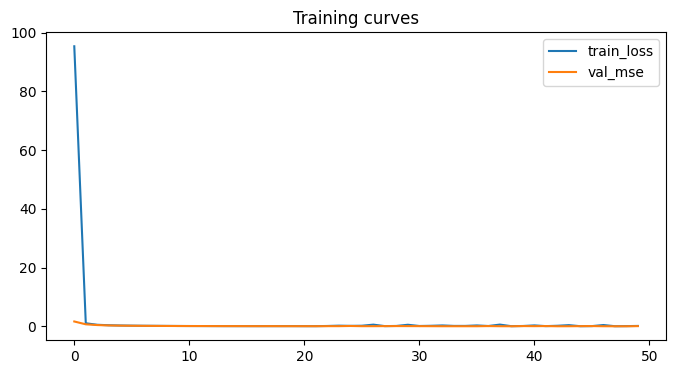

In [ ]:
# Training loop: 放在数据构造与模型定义之后执行
import torch.optim as optim

# 训练配置
in_channels = x.size(1)  # 输入特征维度
hidden_channels = 64  # 隐层维度
learning_rate = 1e-3  # 学习率
weight_decay = 1e-4  # 权重衰减
epochs = 50  # 每窗口训练轮数
patience = 5  # 早停等待轮数
ic_weight = 0.2  # IC损失权重
grad_clip = 1.0  # 梯度裁剪阈值

train_cfg = {'epochs': epochs, 'patience': patience}
loss_cfg = {'ic_weight': ic_weight, 'grad_clip': grad_clip}

print('开始窗口训练...')
window_results = []
global_best_ic = -1e9
global_best_state = None

for window_id, (train_idx, val_idx) in enumerate(window_splits, start=1):
    print(f'窗口 {window_id}/{len(window_splits)} 开始训练')
    model = StockRGCN_Regression(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        num_relations=len(rel_names)
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    best_state, best_ic, history = train_one_window(
        model, optimizer, data_list, train_idx, val_idx, train_cfg, loss_cfg
    )
    window_results.append({
        'window_id': window_id,
        'best_val_ic': best_ic,
        'train_loss': history['train_loss'],
        'val_mse': history['val_mse'],
        'val_ic': history['val_ic']
    })
    print(f'窗口 {window_id} 完成，最佳 IC={best_ic:.6f}')

    if not np.isnan(best_ic) and best_ic > global_best_ic:
        global_best_ic = best_ic
        global_best_state = best_state

if global_best_state is not None:
    torch.save(global_best_state, 'best_model.pt')
    print('已保存 best_model.pt')
else:
    print('未产生可用模型，请检查数据与配置。')

metrics = {
    'window_results': window_results,
    'global_best_ic': global_best_ic,
    'train_window': train_window,
    'val_window': val_window,
    'step': step,
    'epochs': epochs,
    'patience': patience,
    'ic_weight': ic_weight,
    'hidden_channels': hidden_channels,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f)
print('已保存 metrics.json')

# 绘制最后一个窗口的训练曲线（若有）
if len(window_results) > 0:
    last_history = window_results[-1]
    plt.figure(figsize=(8, 4))
    plt.plot(last_history['train_loss'], label='train_loss')
    plt.plot(last_history['val_mse'], label='val_mse')
    plt.plot(last_history['val_ic'], label='val_ic')
    plt.legend()
    plt.title('Training curves (last window)')
    plt.savefig('training_curves.png')
    print('已保存 training_curves.png')